In [3]:
import shutil
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

In [ ]:
#============NEW============
SPLIT_ROOT = Path(
    "C:/Users/ASUS/Desktop/MachineLearning/git/processed_aug"
)  

print(f"Using data folder: {SPLIT_ROOT}")

LABELS = ["accept", "reject"]

for split in ["train", "val", "test"]:
    split_dir = SPLIT_ROOT / split
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing split folder: {split_dir}")

    for label in LABELS:
        label_dir = split_dir / label
        if not label_dir.exists():
            raise FileNotFoundError(f"Missing class folder: {label_dir}")

print("Directory structure is OK.")


Using data folder: C:\Users\ASUS\Desktop\MachineLearning\git\processed_aug
Directory structure is OK.


In [ ]:
# simple base transform (used for val + test)
base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# training augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

In [ ]:
train_data = datasets.ImageFolder(SPLIT_ROOT / "train", transform=train_transform)
val_data   = datasets.ImageFolder(SPLIT_ROOT / "val",   transform=base_transform)
test_data  = datasets.ImageFolder(SPLIT_ROOT / "test",  transform=base_transform)
# accept = datasets.ImageFolder(SPLIT_ROOT / "accept",  transform=base_transform)
# reject = datasets.ImageFolder(SPLIT_ROOT / "reject",  transform=base_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

from collections import Counter

def count_classes(dataset):
    # dataset.targets contains class indices (0 = accept, 1 = reject)
    counts = Counter(dataset.targets)
    class_names = dataset.classes  
    return {class_names[i]: counts[i] for i in counts}

train_counts = count_classes(train_data)
val_counts   = count_classes(val_data)
test_counts  = count_classes(test_data)

print("Train:", train_counts)
print("Val:",   val_counts)
print("Test:",  test_counts)



Train: {'accept': 6128, 'reject': 6836}
Val: {'accept': 162, 'reject': 191}
Test: {'accept': 174, 'reject': 185}


In [8]:
#transformation for googlenet
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import googlenet, GoogLeNet_Weights

num_classes = 2  

model = googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model)


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:

class VoiceCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        
      
        self.features = nn.Sequential(
         
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),  
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

           
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),       
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),      
            nn.ReLU(inplace=True),
        
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.0), 
 
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
        
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(inplace=True),
            
            nn.Dropout(0.0), 
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
    
model = VoiceCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {total_params:,}")

VoiceCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): AdaptiveAvgPool2d(output_size=(4, 4))
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=1024, out_features=128, bias=Tru

In [25]:
# Simple CNN: 3 conv blocks 
class SimpleVoiceCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, len(LABELS)),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SimpleVoiceCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {total_params:,}")


SimpleVoiceCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)
Total parameters: 8,482,626


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# ResNet34-based model
NUM_CLASSES = len(LABELS)
class VoiceResNet34(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.model = models.resnet34(weights="IMAGENET1K_V1")

    
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

model = VoiceResNet34().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

VoiceResNet34(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [10]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [11]:
# Training loop (basic tutorial-style)
history = []
print(f"Model training on device: {model}")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})
    print(f"Epoch {epoch:02d} | Train loss {train_loss:.4f} acc {train_acc:.3f} | Val loss {val_loss:.4f} acc {val_acc:.3f}")


Model training on device: VoiceCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): AdaptiveAvgPool2d(output_size=(4, 4))
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=1024, 

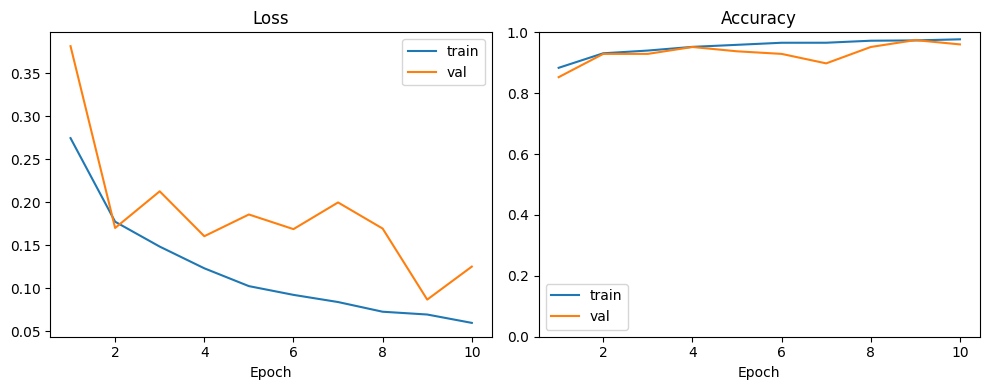

In [12]:
# Plot training curves
import matplotlib.pyplot as plt

epochs = [row["epoch"] for row in history]
train_losses = [row["train_loss"] for row in history]
val_losses = [row["val_loss"] for row in history]
train_accs = [row["train_acc"] for row in history]
val_accs = [row["val_acc"] for row in history]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="train")
plt.plot(epochs, val_losses, label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="train")
plt.plot(epochs, val_accs, label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()
torch.save(model.state_dict(), 'final_cnn.pth')


In [13]:
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            predicted = pred.argmax(dim=1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    return correct / total

print("Running final TEST evaluation...")
test_acc = evaluate(model, test_loader, device)
print(f"TEST Accuracy: {test_acc * 100:.2f}%")


Running final TEST evaluation...
TEST Accuracy: 86.35%


In [14]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        correct += (preds == targets).sum().item()
        total += targets.size(0)

val_acc = correct / total
print("Val accuracy:", val_acc)


Val accuracy: 0.9603399433427762


In [15]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.tolist())

print(classification_report(all_targets, all_preds, target_names=LABELS, digits=4))


              precision    recall  f1-score   support

      accept     0.7803    1.0000    0.8766       174
      reject     1.0000    0.7351    0.8474       185

    accuracy                         0.8635       359
   macro avg     0.8901    0.8676    0.8620       359
weighted avg     0.8935    0.8635    0.8615       359



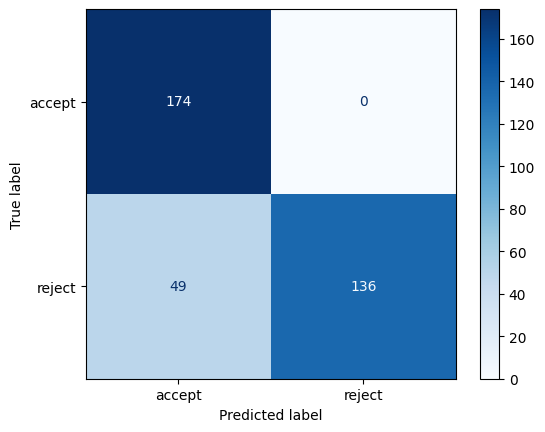

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.tolist())

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap=plt.cm.Blues)
plt.show()
